# Cylindrical Waveguide Analysis

This notebook demonstrates a complete rectangular waveguide analysis workflow:

1. Geometry creation
2. Frequency-domain analysis
3. Model order reduction
4. Comparison with analytical solution

In [1]:
from utils.visualization import *
from geometry.importers import STEPImporter
from solvers.frequency_domain import FrequencyDomainSolver
from rom.reduction import ModelOrderReduction
from analytical.circular_waveguide import CWGAnalytical
from ngsolve.webgui import Draw # must import Draw, otherwise may run into problems showing mesh
from utils.visualization import (
    plot_z_comparison, 
    plot_s_comparison, 
    plot_all_parameters,
    plot_eigenfrequencies,
    ParameterPlotter,
    EigenfrequencyPlotter
)
%matplotlib inline
plt.rcParams['figure.dpi'] = 100

## 1. Define Geometry

Create a rectangular waveguide with specified dimensions and mesh parameters.

In [2]:
# 1. Load and prepare geometry
geo = STEPImporter(r"./circular_waveguide.step", auto_build=False)
geo.add_splitting_plane_at_z(0.075)
geo.add_splitting_plane_at_z(0.15)
geo.split()

geo.show_split_preview()
geo.build()
geo.name_solids()

geo.generate_mesh(maxh=0.04) # after naming solids, must generate mesh but avoid rebuilding

Displayed 3 solids with distinct colors
Displayed 2 splitting plane(s)


In [3]:
geo.show()

WebGuiWidget(layout=Layout(height='50vh', width='100%'), value={'ngsolve_version': 'Netgen x.x', 'mesh_dim': 3…


Structure Topology
Type: Compound structure
Domains (3): ['cell_1', 'cell_2', 'cell_3']
Total Ports (4): ['port1', 'port2', 'port3', 'port4']
External Ports (2): ['port1', 'port4']
Internal Ports (2): ['port2', 'port3']

Domain-Port Mapping:
  cell_1: ['port1 (external, input)', 'port2 (internal)']
  cell_2: ['port2 (internal)', 'port3 (internal)']
  cell_3: ['port3 (internal)', 'port4 (external, output)']

Assembling Matrices...

Solving port eigenmodes...

	Calculating Port Eigenmodes...
	  Mode source: analytic
	  Polarization angle: 0.0°
	  Requested modes per port: 3
	------------------------------------------------------------
	  port3: circular (fit error: 0.0000)
	    R=0.150001
	  port4: circular (fit error: 0.0000)
	    R=0.150001
	  port2: circular (fit error: 0.0000)
	    R=0.150001
	  port1: circular (fit error: 0.0000)
	    R=0.150001
	  Precomputing boundary mass matrices (once per port)...
	    Done for 4 port(s)
	port3 mode 0: TE_11 (cos), kc=12.2745, σ=+1
	port3 mode

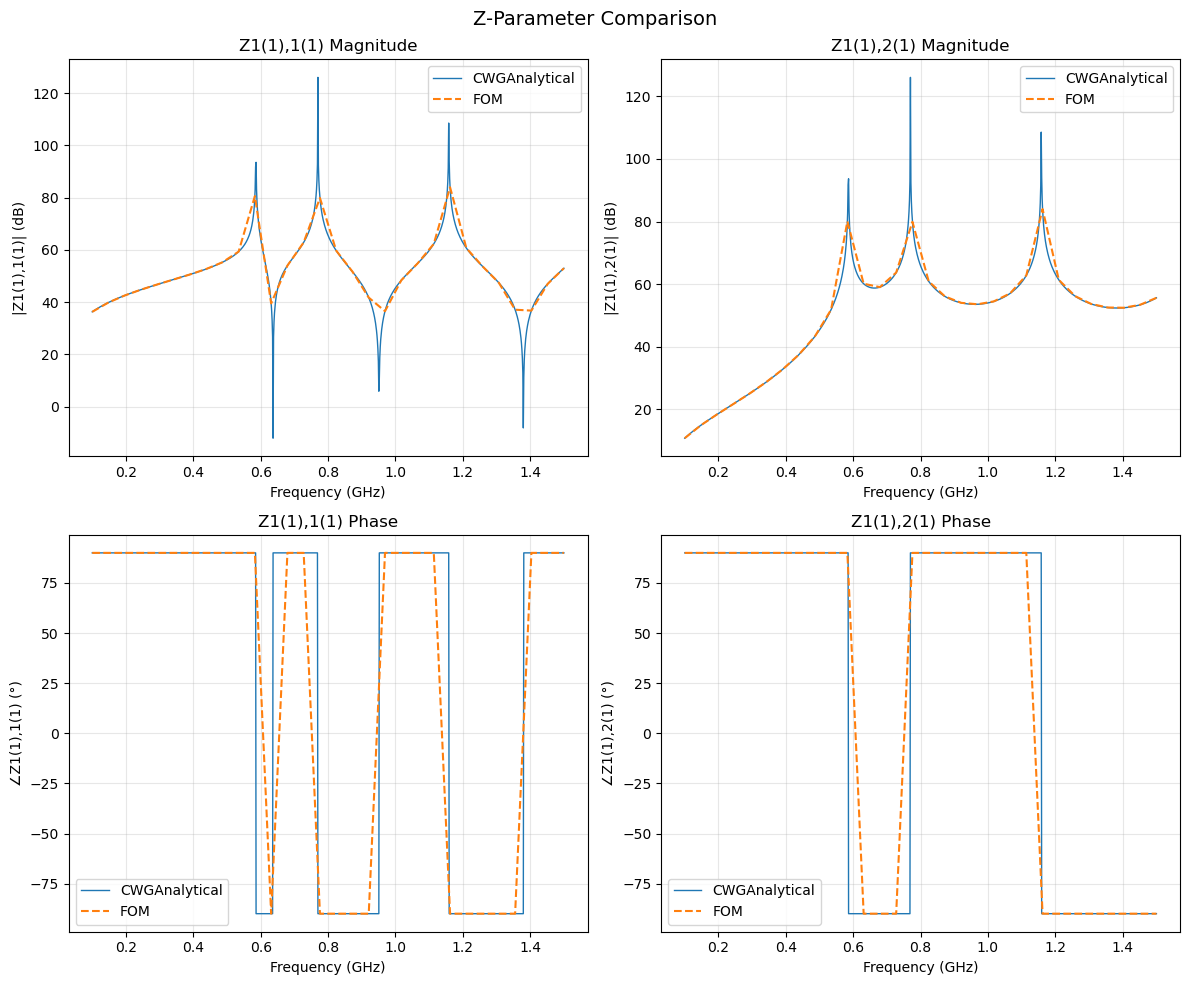

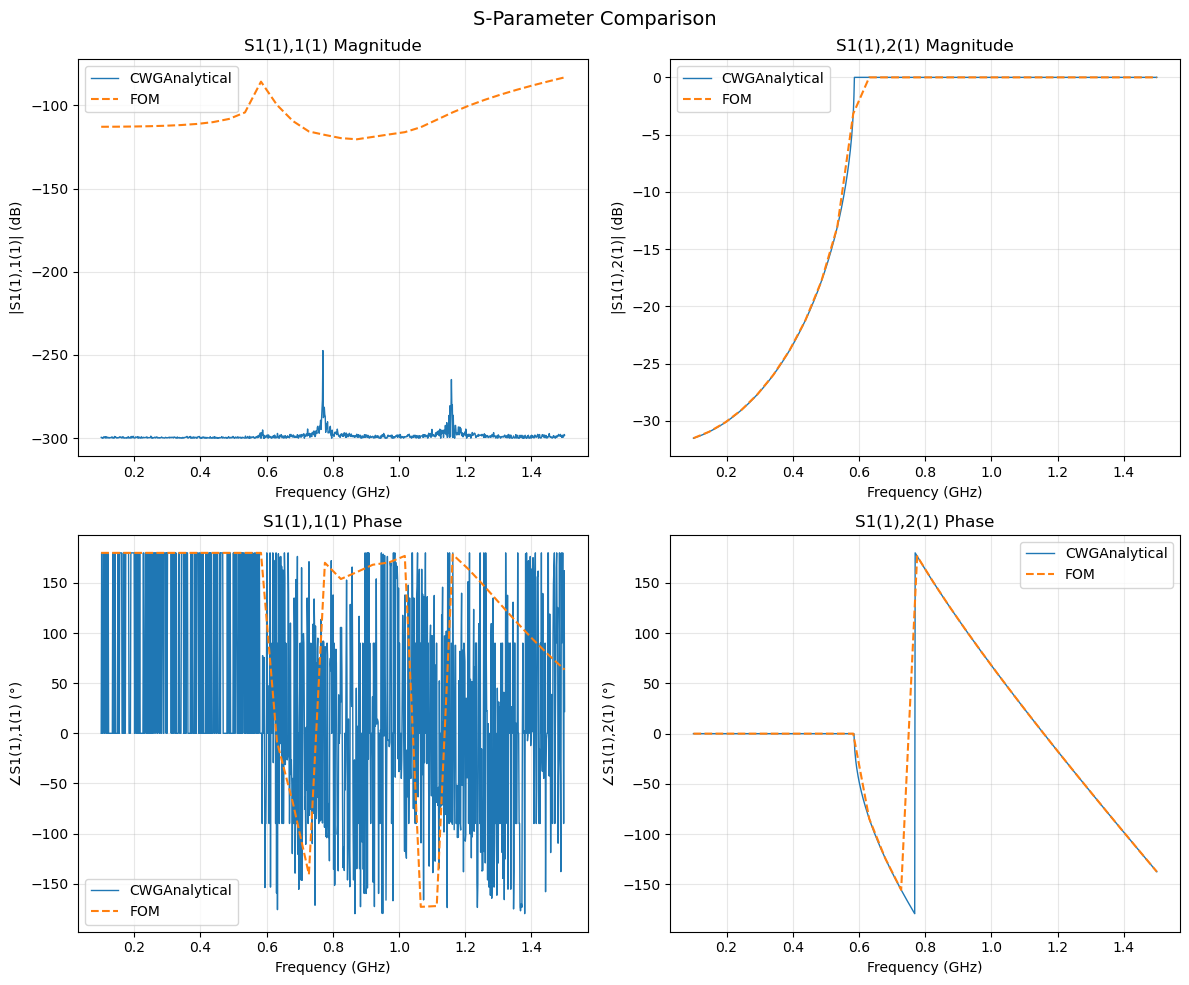

(<Figure size 1200x1000 with 4 Axes>,
 {'S1(1),1(1)_mag': <Axes: title={'center': 'S1(1),1(1) Magnitude'}, xlabel='Frequency (GHz)', ylabel='|S1(1),1(1)| (dB)'>,
  'S1(1),1(1)_phase': <Axes: title={'center': 'S1(1),1(1) Phase'}, xlabel='Frequency (GHz)', ylabel='∠S1(1),1(1) (°)'>,
  'S1(1),2(1)_mag': <Axes: title={'center': 'S1(1),2(1) Magnitude'}, xlabel='Frequency (GHz)', ylabel='|S1(1),2(1)| (dB)'>,
  'S1(1),2(1)_phase': <Axes: title={'center': 'S1(1),2(1) Phase'}, xlabel='Frequency (GHz)', ylabel='∠S1(1),2(1) (°)'>})

In [4]:
# 2. Analytical
radius = 150e-3  # Width: 100 mm
L = 300e-3  # Length: 200 mm
analytical = CWGAnalytical(radius=radius, length=L)

# 3. FOM solve
fds = FrequencyDomainSolver(geo, order=3)
fds.assemble_matrices(nportmodes=3)
fds.solve(0.1, 1.5, 30, store_snapshots=True)

# 4. Quick comparison plots - just pass the objects!
frequencies = np.linspace(0.1, 1.5, 1000) * 1e9
plot_z_comparison([analytical, fds], frequencies=frequencies)
plot_s_comparison([analytical, fds], frequencies=frequencies)

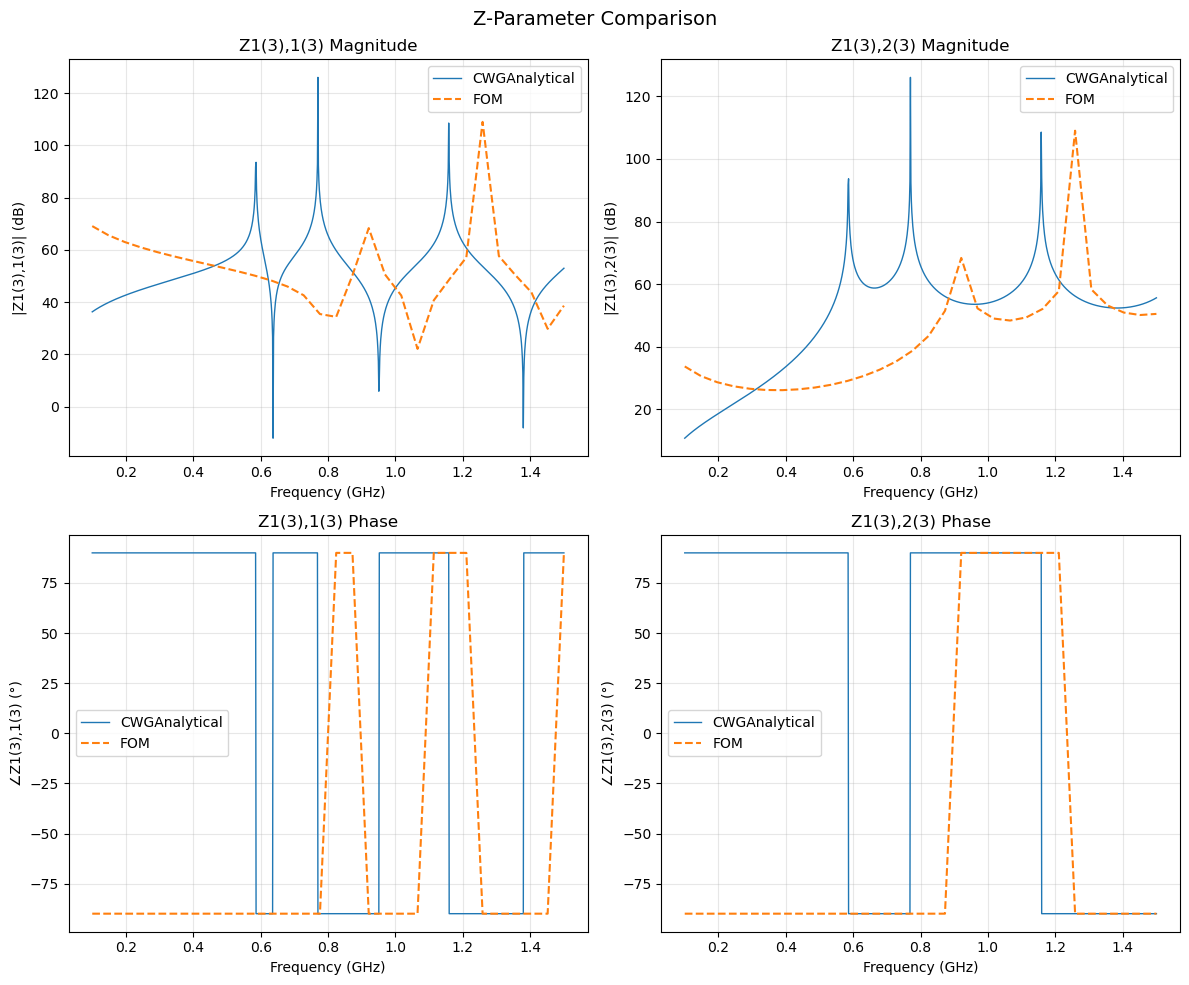

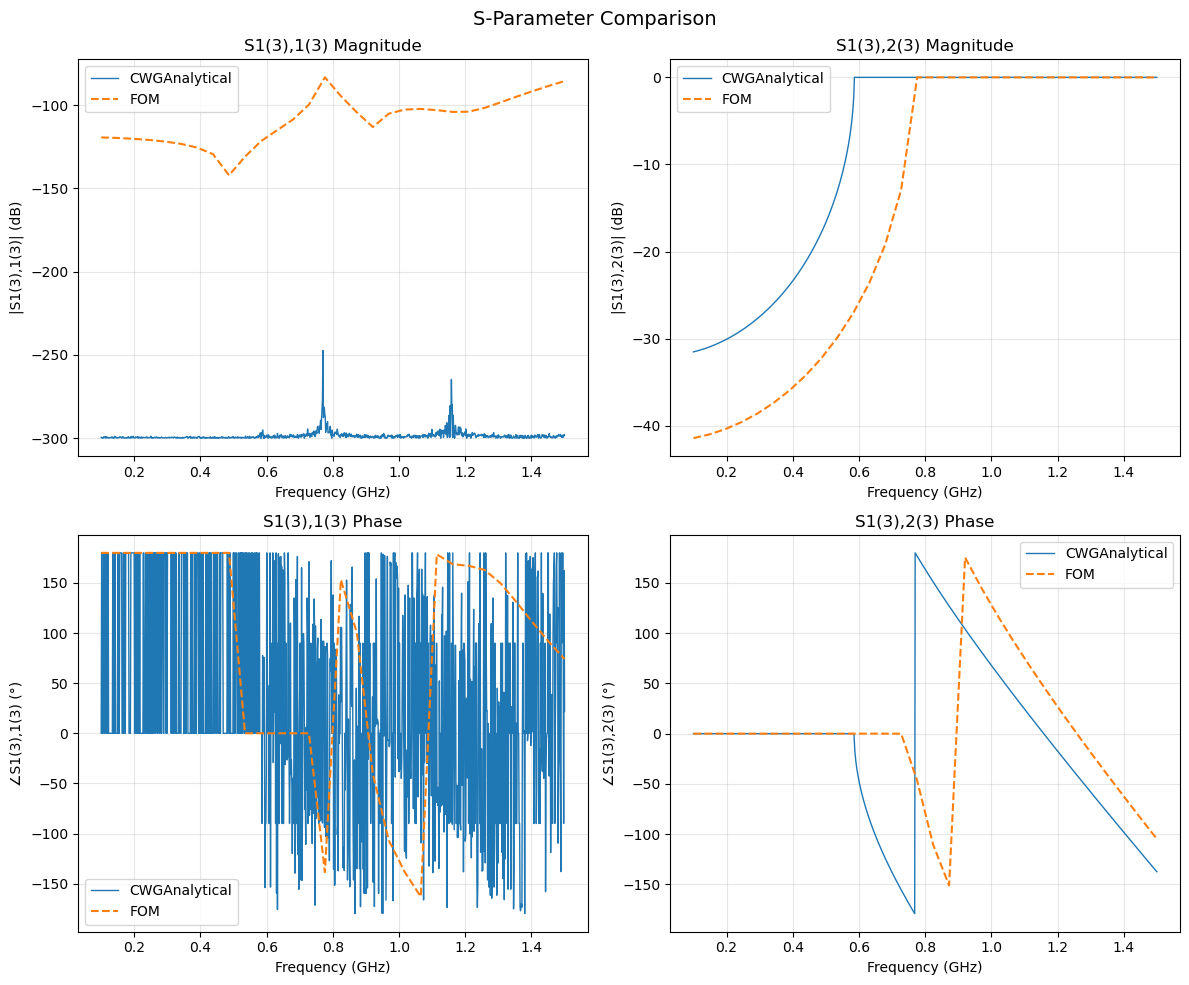

(<Figure size 1200x1000 with 4 Axes>,
 {'S1(3),1(3)_mag': <Axes: title={'center': 'S1(3),1(3) Magnitude'}, xlabel='Frequency (GHz)', ylabel='|S1(3),1(3)| (dB)'>,
  'S1(3),1(3)_phase': <Axes: title={'center': 'S1(3),1(3) Phase'}, xlabel='Frequency (GHz)', ylabel='∠S1(3),1(3) (°)'>,
  'S1(3),2(3)_mag': <Axes: title={'center': 'S1(3),2(3) Magnitude'}, xlabel='Frequency (GHz)', ylabel='|S1(3),2(3)| (dB)'>,
  'S1(3),2(3)_phase': <Axes: title={'center': 'S1(3),2(3) Phase'}, xlabel='Frequency (GHz)', ylabel='∠S1(3),2(3) (°)'>})

In [5]:

plot_z_comparison([analytical, fds], frequencies=frequencies, mode_pairs=[(3, 3), (3, 3)])
plot_s_comparison([analytical, fds], frequencies=frequencies, mode_pairs=[(3, 3), (3, 3)])

In [6]:
# # Solve with concatenation method
# fds = FrequencyDomainSolver(geo, order=3)
# fds.assemble_matrices(nportmodes=1)

# # Option 1: Use concatenate directly
# results = fds.solve(0.1, 3, 100, 
#                     per_domain=True, 
#                     global_method='concatenate')

# # Option 2: Compare all methods
# comparison = fds.compare_methods(0.1, 3, 100, 
#                                   methods=['coupled', 'cascade', 'concatenate'])

# # The concatenate method should match coupled exactly (within numerical precision)
# # while cascade may show errors if there are significant inter-domain reflections

In [7]:
# # 6. Eigenfrequency comparison
# fig, ax = plot_eigenfrequencies([fds], analytical=analytical, n_modes=35)
# ax.set_ylim(1, 5)
# ax.set_xlim(1, 5)


Model Order Reduction

Domain: cell_1
  Full DOFs: 13392
  Snapshots: 180
  Reduced DOFs: 28
  Compression: 99.8%
  Singular value decay: 1.76e+05 → 8.03e-02

Domain: cell_2
  Full DOFs: 12805
  Snapshots: 180
  Reduced DOFs: 28
  Compression: 99.8%
  Singular value decay: 1.69e+05 → 8.49e-02

Domain: cell_3
  Full DOFs: 20951
  Snapshots: 180
  Reduced DOFs: 26
  Compression: 99.9%
  Singular value decay: 3.56e+06 → 3.47e+00

------------------------------------------------------------
Total: 47148 → 82 DOFs
Overall compression: 99.8%

Coupled system: 82 -> 76 DOFs
External port-modes: 6, Internal port-modes: 12
Port connections: 2 (× 3 modes each)


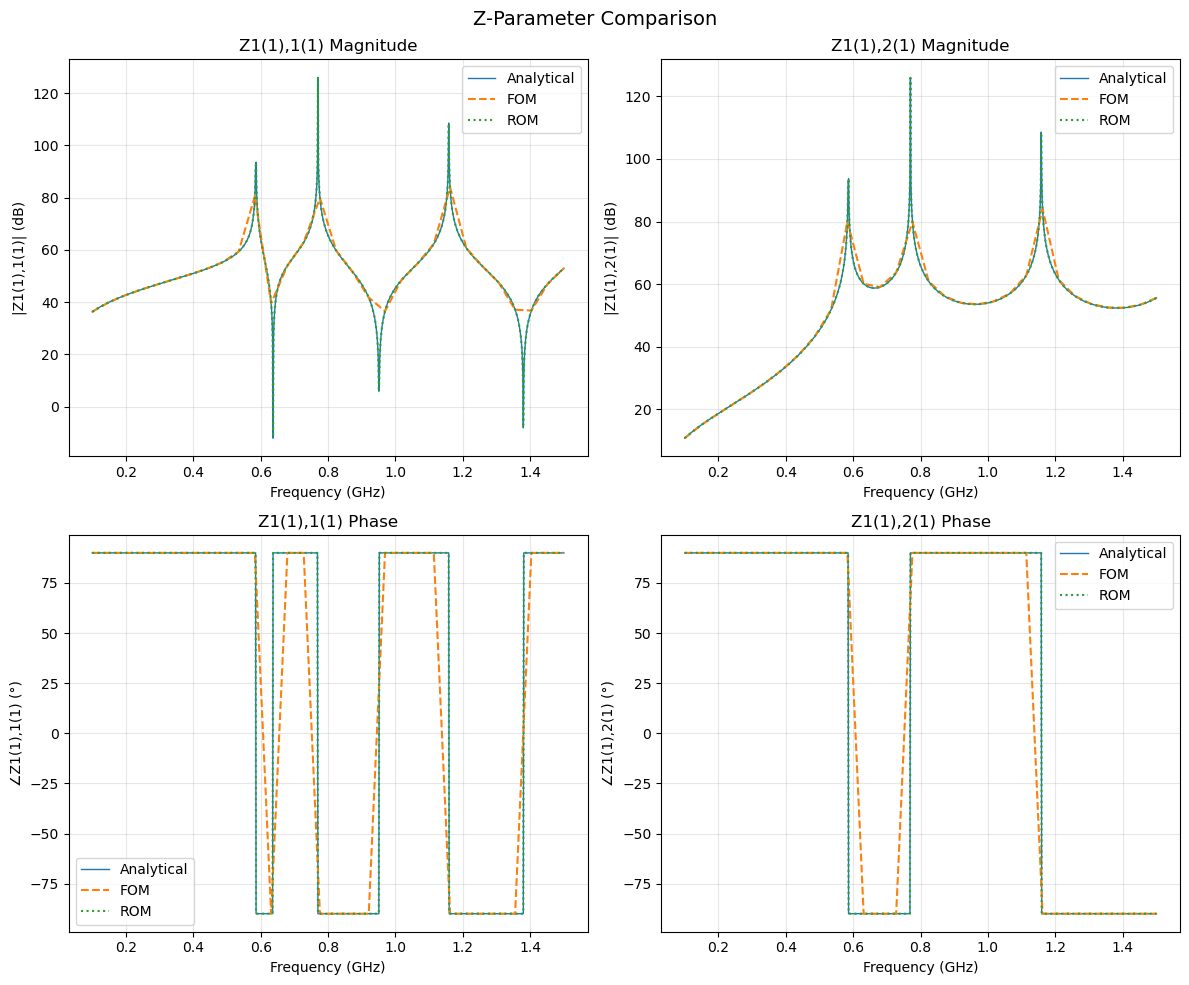

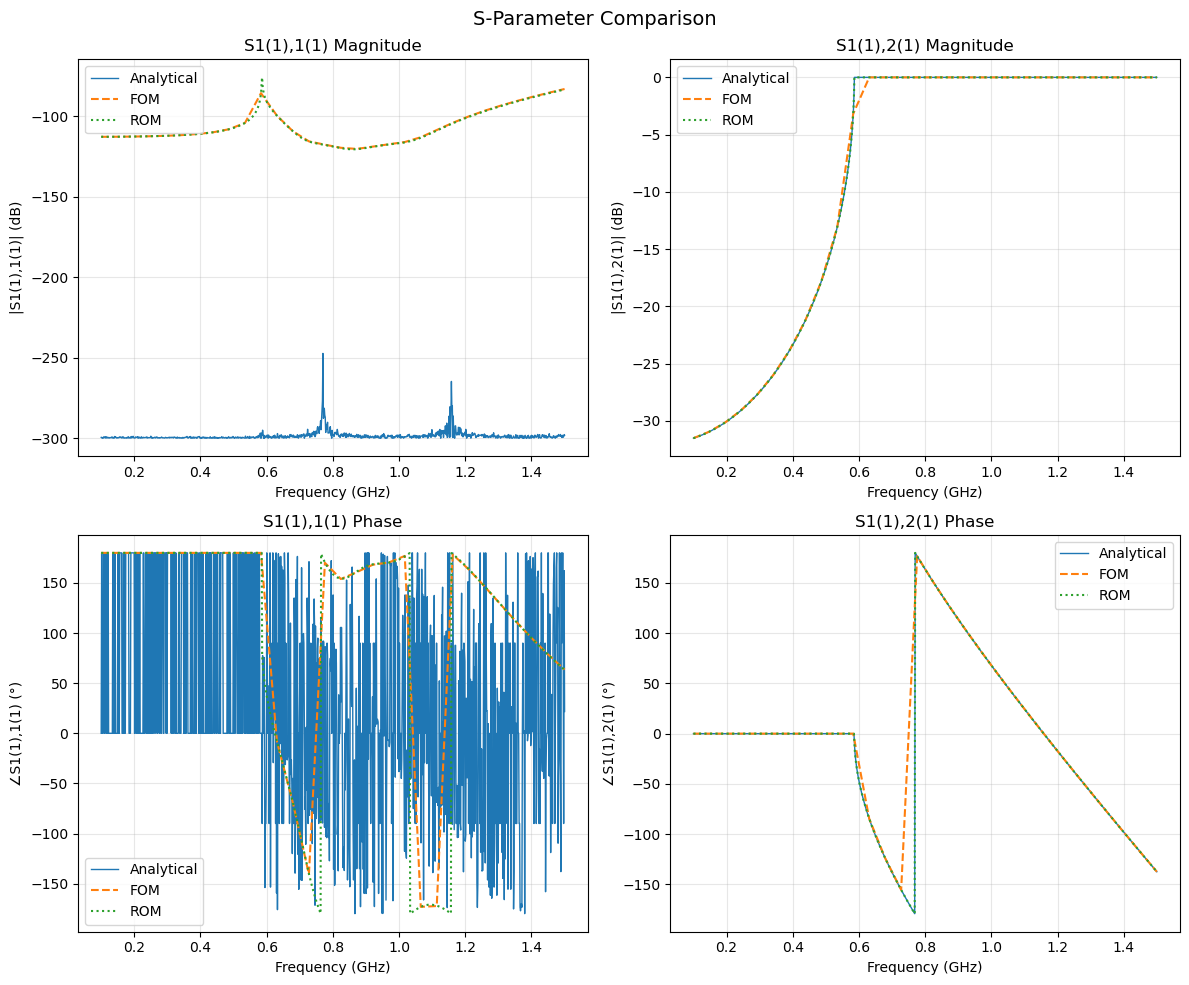

(<Figure size 1200x1000 with 4 Axes>,
 {'S1(1),1(1)_mag': <Axes: title={'center': 'S1(1),1(1) Magnitude'}, xlabel='Frequency (GHz)', ylabel='|S1(1),1(1)| (dB)'>,
  'S1(1),1(1)_phase': <Axes: title={'center': 'S1(1),1(1) Phase'}, xlabel='Frequency (GHz)', ylabel='∠S1(1),1(1) (°)'>,
  'S1(1),2(1)_mag': <Axes: title={'center': 'S1(1),2(1) Magnitude'}, xlabel='Frequency (GHz)', ylabel='|S1(1),2(1)| (dB)'>,
  'S1(1),2(1)_phase': <Axes: title={'center': 'S1(1),2(1) Phase'}, xlabel='Frequency (GHz)', ylabel='∠S1(1),2(1) (°)'>})

In [8]:
# After ROM is working...
from rom.reduction import ModelOrderReduction

rom = ModelOrderReduction(fds)
rom.reduce(max_rank=30, tol=1e-6)
rom.solve(0.1, 1.5, 1000)

# Compare all three
plot_z_comparison([analytical, fds, rom], frequencies=frequencies,
                  labels=['Analytical', 'FOM', 'ROM'])
plot_s_comparison([analytical, fds, rom], frequencies=frequencies,
                  labels=['Analytical', 'FOM', 'ROM'])



Model Order Reduction

Domain: cell_1
  Full DOFs: 13392
  Snapshots: 180
  Reduced DOFs: 28
  Compression: 99.8%
  Singular value decay: 1.76e+05 → 8.03e-02

Domain: cell_2
  Full DOFs: 12805
  Snapshots: 180
  Reduced DOFs: 28
  Compression: 99.8%
  Singular value decay: 1.69e+05 → 8.49e-02

Domain: cell_3
  Full DOFs: 20951
  Snapshots: 180
  Reduced DOFs: 26
  Compression: 99.9%
  Singular value decay: 3.56e+06 → 3.47e+00

------------------------------------------------------------
Total: 47148 → 82 DOFs
Overall compression: 99.8%

Coupled system: 82 -> 76 DOFs
External port-modes: 6, Internal port-modes: 12
Port connections: 2 (× 3 modes each)


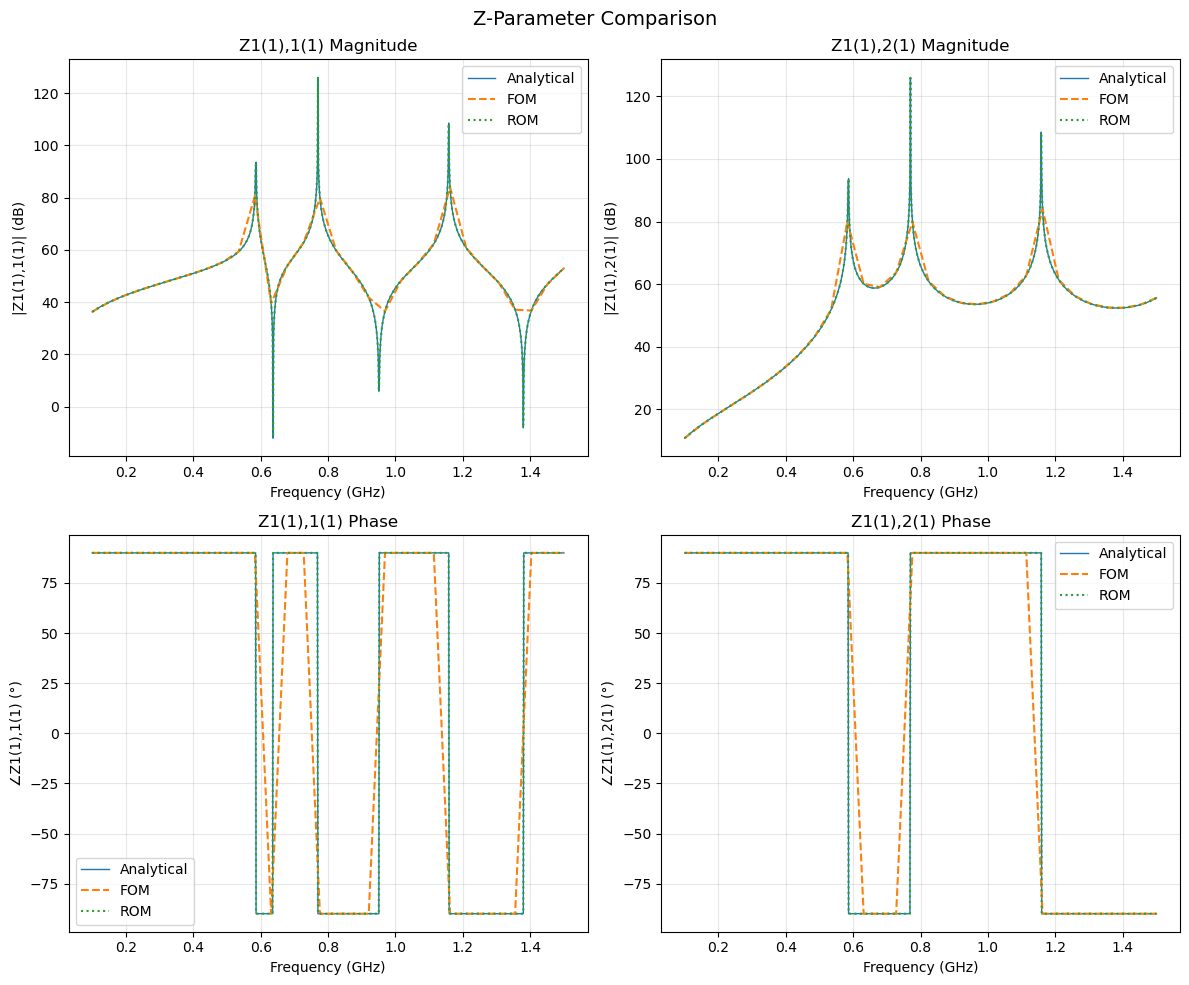

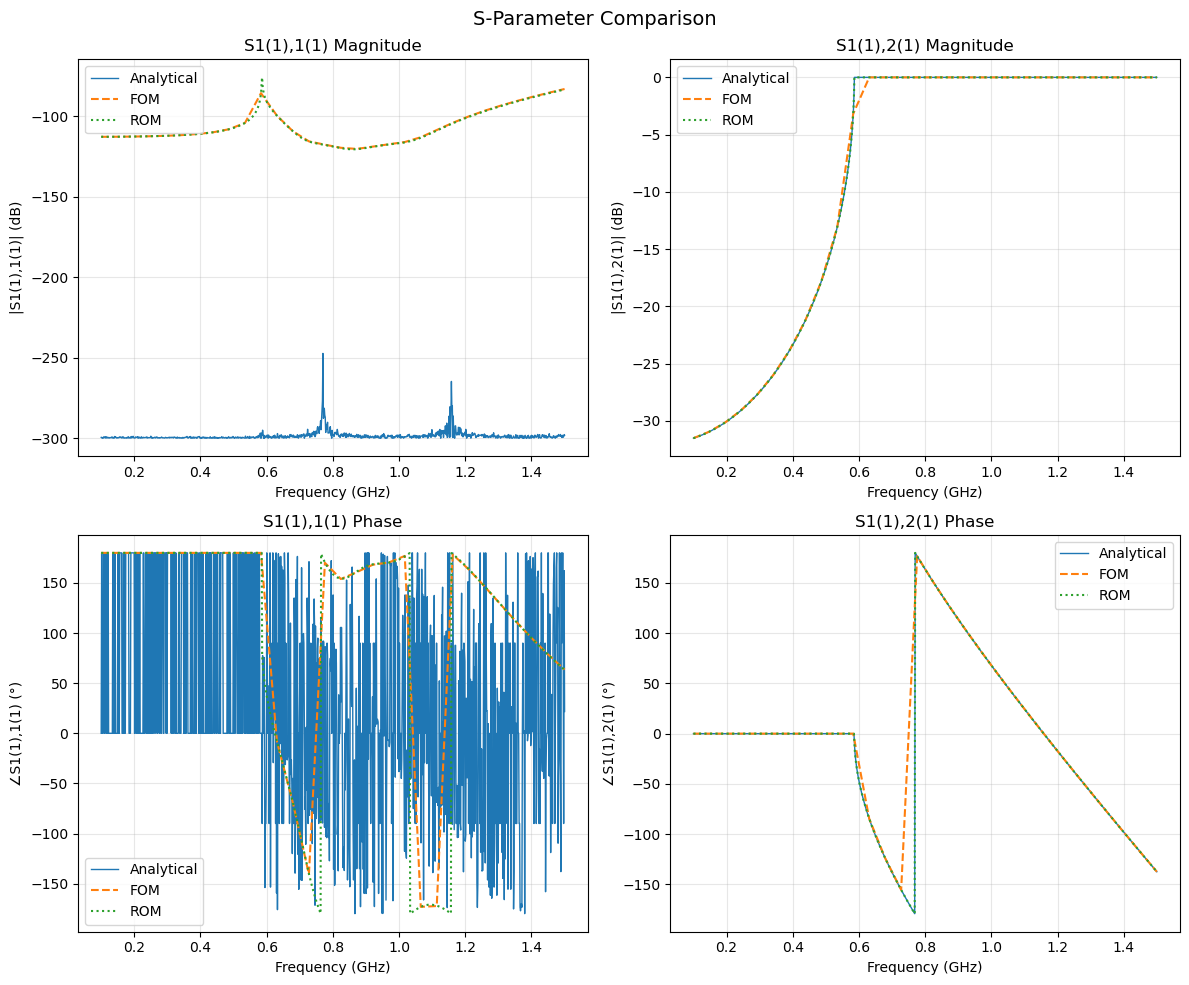

(<Figure size 1200x1000 with 4 Axes>,
 {'S1(1),1(1)_mag': <Axes: title={'center': 'S1(1),1(1) Magnitude'}, xlabel='Frequency (GHz)', ylabel='|S1(1),1(1)| (dB)'>,
  'S1(1),1(1)_phase': <Axes: title={'center': 'S1(1),1(1) Phase'}, xlabel='Frequency (GHz)', ylabel='∠S1(1),1(1) (°)'>,
  'S1(1),2(1)_mag': <Axes: title={'center': 'S1(1),2(1) Magnitude'}, xlabel='Frequency (GHz)', ylabel='|S1(1),2(1)| (dB)'>,
  'S1(1),2(1)_phase': <Axes: title={'center': 'S1(1),2(1) Phase'}, xlabel='Frequency (GHz)', ylabel='∠S1(1),2(1) (°)'>})

In [9]:
# After ROM is working...
from rom.reduction import ModelOrderReduction

rom = ModelOrderReduction(fds)
rom.reduce(max_rank=30, tol=1e-6)
rom.solve(0.1, 1.5, 1000)

# Compare all three
plot_z_comparison([analytical, fds, rom], frequencies=frequencies,
                  labels=['Analytical', 'FOM', 'ROM'])
plot_s_comparison([analytical, fds, rom], frequencies=frequencies,
                  labels=['Analytical', 'FOM', 'ROM'])


In [10]:
print(rom._concatenated.n_total_ports)
print(rom._concatenated._internal_ports)
print(rom._concatenated._external_ports)
print(rom._concatenated._global_to_local)
print(rom._concatenated.connections)

AttributeError: 'ConcatenatedSystem' object has no attribute 'n_total_ports'

In [ ]:
fig, ax = plot_eigenfrequencies([fds, rom], analytical=analytical,
                      labels=['FOM', 'ROM'], n_modes=50)
ax.set_ylim(1, 5)
ax.set_xlim(1, 5)

## Summary

This analysis demonstrated:
- **Geometry creation** for a rectangular waveguide
- **Full-order FEM** frequency domain analysis
- **Model order reduction** using POD with significant compression
- **Validation** against analytical solutions

The ROM provides accurate results with substantially reduced computational cost.